In [14]:
import librosa as lb
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
keys, sr = lb.load('data/keys.wav')
print(keys)
print(sr)

[-0.00081816 -0.00317483 -0.00513814 ...  0.01177182  0.01169396
  0.0072737 ]
22050


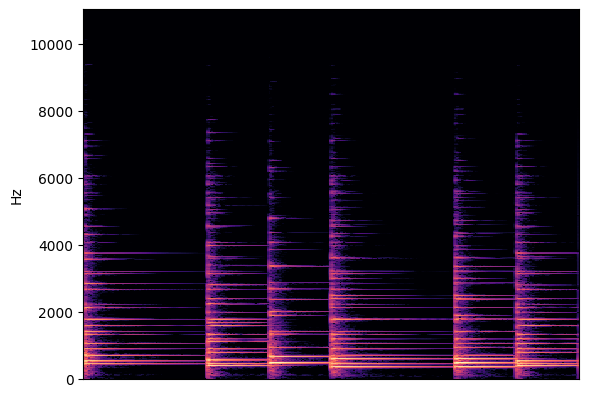

In [33]:
D = lb.amplitude_to_db(np.abs(lb.stft(keys)), ref=np.max)
lb.display.specshow(D, y_axis='hz')

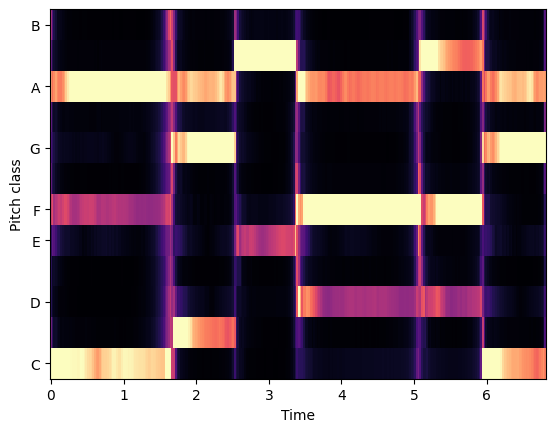

In [54]:
chromagram = lb.feature.chroma_cqt(y=keys, sr=sr)
lb.display.specshow(chromagram, y_axis='chroma', x_axis='time')

# Chords

In [49]:
maj_template = np.array([1,0,0, 0,1,0, 0,1,0, 0,0,0])
min_template = np.array([1,0,0, 1,0,0, 0,1,0, 0,0,0])
N_template   = np.array([1,1,1, 1,1,1, 1,1,1, 1,1,1.]) / 4.

weights = np.zeros((25, 12), dtype=float)
labels = ['C:maj', 'C#:maj', 'D:maj', 'D#:maj', 'E:maj', 'F:maj',
          'F#:maj', 'G:maj', 'G#:maj', 'A:maj', 'A#:maj', 'B:maj',
          'C:min', 'C#:min', 'D:min', 'D#:min', 'E:min', 'F:min',
          'F#:min', 'G:min', 'G#:min', 'A:min', 'A#:min', 'B:min',
          'N']
print(len(labels))
for c in range(12):
    weights[c, :] = np.roll(maj_template, c) # c:maj
    weights[c + 12, :] = np.roll(min_template, c)  # c:min
weights[24, :] = N_template
#print(weights)
#Self-loop transition matrix:
#The probability of staying in the same state is 0.9, and the probability of transitioning to any other state is uniformly distributed among the remaining states (0.1 / 24).
trans = lb.sequence.transition_loop(25, 0.9)
trans;

25


In [64]:
chroma = lb.feature.chroma_cqt(y=keys, sr=sr)
# Map chroma (observations) to class (state) likelihoods
probs = np.exp(weights.dot(chroma))  # P[class | chroma] ~= exp(template' chroma)
probs /= probs.sum(axis=0, keepdims=True)  # probabilities must sum to 1 in each column
# Compute independent frame-wise estimates
chords_ind = np.argmax(probs, axis=0)
# And viterbi estimates
chords_vit = lb.sequence.viterbi_discriminative(probs, trans)
chords_vit.shape

(294,)

In [66]:
# Convert the numerical indices into chord names
predicted_chords = [labels[i] for i in chords_vit]

predicted_chords_unique = []
for chord in predicted_chords:
    if not predicted_chords_unique or chord != predicted_chords_unique[-1]:
        predicted_chords_unique.append(chord)

print(predicted_chords_unique)

['F:maj', 'A:maj', 'A#:maj', 'D:min', 'A#:maj', 'C:maj']


when u add beats, check out harmonic-percussive source separation

viterbi infers chords (hidden state) from a chromagram. could you train a model (random forest?) with a large number of melodies (training) and their chord progressions (testing)?